# XGBoost Prediction: Descriptor Baseline under Random vs Multilabel-Stratified 5-Fold CV

This notebook is the XGBoost-only comparison baseline for Tox21 using RDKit 2D normalized descriptors.

We freeze the XGBoost hyperparameters to the best descriptor-based setting recovered from the saved interim notebook output and use this notebook only for evaluation under two fold-generation strategies:

1. `random` 5-fold cross-validation
2. `multilabel_iterstrat` 5-fold cross-validation with `scikit-multilearn`

Methodology note:
- Reportable scalar metrics are the **mean and standard deviation across validation folds**.
- ROC and PR curves are generated from **pooled out-of-fold (OOF) predictions** across all 5 folds, so every sample is evaluated exactly once out of sample.
- We do **not** take the best fold or a single best model for the final plots, because that would bias the comparison.

## 1. Import Necessary Modules and Libraries

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:

    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)


from descriptastorus.descriptors import rdNormalizedDescriptors
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import KFold

try:
    from skmultilearn.model_selection import IterativeStratification
except ModuleNotFoundError as exc:
    raise ImportError(
        "scikit-multilearn is required for the multilabel iterative stratified evaluation in this notebook. "
        "Install it with `python -m pip install scikit-multilearn` or sync the project environment."
    ) from exc

## 2. Configuration and Fixed XGBoost Parameters

In [2]:
# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Data paths ---
DATA_ROOT = Path("data")
TRAIN_CSV = DATA_ROOT / "Train" / "tox21_train_clean.csv"
VAL_CSV = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TEST_CSV = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

# --- Fixed descriptor-XGBoost hyperparameters recovered from the saved interim notebook output ---
INTERIM_NOTEBOOK_URL = "https://github.com/iamthomaspruyn/AI-for-Toxicology/blob/main/Interim_Report/XGBoost_Implementation.ipynb"
FIXED_XGB_PARAMS = {
    "max_depth": 7,
    "n_estimators": 300,
    "learning_rate": 0.03,
    "reg_alpha": 1.0,
    "gamma": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "objective": "binary:logistic",
}

N_FOLDS = 5
STRATEGY_ORDER = ["random", "multilabel_iterstrat"]
STRATEGY_LABELS = {
    "random": "Random 5-Fold CV",
    "multilabel_iterstrat": "Multilabel Iterative Stratified 5-Fold CV",
}
GLOBAL_METRICS = ["macro_auroc", "macro_auprc", "micro_auroc", "micro_auprc"]
PER_TASK_METRICS = ["AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]

descriptor_generator = rdNormalizedDescriptors.RDKit2DNormalized()
DESCRIPTOR_NAMES = list(descriptor_generator.columns)

print("Fixed XGBoost parameters:")
print(FIXED_XGB_PARAMS)
print(f"Descriptor count: {len(DESCRIPTOR_NAMES)}")
print(f"Interim notebook source: {INTERIM_NOTEBOOK_URL}")

Fixed XGBoost parameters:
{'max_depth': 7, 'n_estimators': 300, 'learning_rate': 0.03, 'reg_alpha': 1.0, 'gamma': 3, 'subsample': 0.8, 'colsample_bytree': 0.5, 'objective': 'binary:logistic'}
Descriptor count: 200
Interim notebook source: https://github.com/iamthomaspruyn/AI-for-Toxicology/blob/main/Interim_Report/XGBoost_Implementation.ipynb


## 3. Load Tox21 Data and Build the Descriptor Matrix

In [3]:
def load_tox21_frame(path: Path, origin_split: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")

    task_cols = [c for c in df.columns if c.startswith("NR-") or c.startswith("SR-")]
    if not task_cols:
        raise ValueError(f"{path} does not contain Tox21 task columns")

    df = df.dropna(subset=["canonical_smiles"]).reset_index(drop=True).copy()
    df["canonical_smiles"] = df["canonical_smiles"].astype(str)
    df[task_cols] = df[task_cols].apply(pd.to_numeric, errors="coerce")
    df["origin_split"] = origin_split
    return df


def descriptor_from_smiles(smiles: str):
    res = descriptor_generator.process(smiles)
    if not res[0]:
        return None

    vec = np.asarray(res[1:], dtype=np.float32)
    if vec.shape[0] != len(DESCRIPTOR_NAMES):
        return None
    if not np.isfinite(vec).all():
        return None

    return vec


def build_descriptor_dataset(
    df: pd.DataFrame, tasks: list[str], dataset_name: str
) -> dict:
    desc_rows = []
    y_rows = []
    meta_rows = []
    fail_desc = 0
    fail_label = 0

    for _, row in df.iterrows():
        smiles = str(row["canonical_smiles"])
        y_row = row[tasks].to_numpy(dtype=float)

        if not np.isfinite(y_row).all():
            fail_label += 1
            continue

        y_row = y_row.astype(int)
        if not np.isin(y_row, [0, 1]).all():
            fail_label += 1
            continue

        desc = descriptor_from_smiles(smiles)
        if desc is None:
            fail_desc += 1
            continue

        desc_rows.append(desc)
        y_rows.append(y_row)
        meta_rows.append(
            {
                "canonical_smiles": smiles,
                "origin_split": row["origin_split"],
            }
        )

    if not desc_rows:
        raise RuntimeError("No samples left after descriptor/label filtering.")

    X = np.vstack(desc_rows).astype(np.float32)
    Y = np.vstack(y_rows).astype(np.int64)
    meta = pd.DataFrame(meta_rows).reset_index(drop=True)
    meta["aligned_idx"] = np.arange(len(meta))

    stats = {
        "input_rows": int(len(df)),
        "kept_rows": int(len(Y)),
        "fail_desc": int(fail_desc),
        "fail_label": int(fail_label),
    }

    return {
        "name": dataset_name,
        "X": X,
        "y": Y,
        "meta": meta,
        "stats": stats,
    }


train_df_raw = load_tox21_frame(TRAIN_CSV, "train")
val_df_raw = load_tox21_frame(VAL_CSV, "val")
test_df_raw = load_tox21_frame(TEST_CSV, "test")
all_df_raw = pd.concat([train_df_raw, val_df_raw, test_df_raw], ignore_index=True)

TASKS = [c for c in train_df_raw.columns if c.startswith("NR-") or c.startswith("SR-")]
descriptor_dataset = build_descriptor_dataset(
    all_df_raw, TASKS, dataset_name="tox21_descriptor_ready"
)

print(f"Tasks ({len(TASKS)}): {TASKS}")
print("Descriptor-ready dataset stats:")
print(descriptor_dataset["stats"])
print(f"Descriptor matrix shape: {descriptor_dataset['X'].shape}")
print(f"Label matrix shape     : {descriptor_dataset['y'].shape}")

origin_summary_df = (
    descriptor_dataset["meta"]["origin_split"]
    .value_counts()
    .rename_axis("origin_split")
    .reset_index(name="n_descriptor_ready")
)

positive_rate_df = (
    pd.DataFrame(descriptor_dataset["y"], columns=TASKS)
    .mean()
    .to_frame("positive_rate")
    .T
)

display(origin_summary_df)
display(positive_rate_df)

[13:01:36] WARNING: not removing hydrogen atom without neighbors
[13:01:36] WARNING: not removing hydrogen atom without neighbors


Tasks (12): ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Descriptor-ready dataset stats:
{'input_rows': 7823, 'kept_rows': 7730, 'fail_desc': 93, 'fail_label': 0}
Descriptor matrix shape: (7730, 200)
Label matrix shape     : (7730, 12)


,origin_split,n_descriptor_ready
0,train,6178
1,val,777
2,test,775


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
positive_rate,0.039715,0.029495,0.099353,0.038551,0.101682,0.043079,0.021992,0.117982,0.03273,0.044631,0.116559,0.052652


## 4. Cross-Validation Utilities and Evaluation Logic

In [4]:
def _to_prob_matrix(y_probs_raw):
    if isinstance(y_probs_raw, list):
        return np.transpose([pred[:, 1] for pred in y_probs_raw])

    arr = np.asarray(y_probs_raw)
    if arr.ndim == 3 and arr.shape[-1] == 2:
        return arr[:, :, 1]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"Unexpected probability output shape: {arr.shape}")


def _macro_auroc(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        if np.unique(yj).size < 2:
            continue
        vals.append(roc_auc_score(yj, y_probs[:, j]))
    return float(np.mean(vals)) if vals else np.nan


def _macro_auprc(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        if np.unique(yj).size < 2:
            continue
        vals.append(average_precision_score(yj, y_probs[:, j]))
    return float(np.mean(vals)) if vals else np.nan


def _micro_auroc(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    y_flat = y_true.ravel()
    p_flat = y_probs.ravel()
    if np.unique(y_flat).size < 2:
        return np.nan
    return float(roc_auc_score(y_flat, p_flat))


def _micro_auprc(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    y_flat = y_true.ravel()
    p_flat = y_probs.ravel()
    if np.unique(y_flat).size < 2:
        return np.nan
    return float(average_precision_score(y_flat, p_flat))


def compute_global_metrics(y_true: np.ndarray, y_probs: np.ndarray) -> dict:
    return {
        "macro_auroc": _macro_auroc(y_true, y_probs),
        "macro_auprc": _macro_auprc(y_true, y_probs),
        "micro_auroc": _micro_auroc(y_true, y_probs),
        "micro_auprc": _micro_auprc(y_true, y_probs),
    }


def _binary_metrics(
    y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5
) -> dict:
    y_true = y_true.astype(int)
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": (
            float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan
        ),
        "Precision": (
            float(precision_score(y_true, y_hat, zero_division=0))
            if len(y_true)
            else np.nan
        ),
        "Recall": (
            float(recall_score(y_true, y_hat, zero_division=0))
            if len(y_true)
            else np.nan
        ),
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out


def _safe_mean(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if len(vals) else np.nan


def _safe_std(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.std(ddof=1)) if len(vals) > 1 else np.nan


def make_cv_splits(y: np.ndarray, strategy: str, n_splits: int = 5, seed: int = 42):
    if strategy == "random":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(splitter.split(np.arange(len(y))))

    if strategy == "multilabel_iterstrat":
        perm = np.random.default_rng(seed).permutation(len(y))
        y_perm = y[perm]
        dummy = np.zeros((len(y_perm), 1), dtype=np.int64)
        splitter = IterativeStratification(n_splits=n_splits, order=1)
        splits = []
        for train_rel, val_rel in splitter.split(dummy, y_perm):
            splits.append((perm[train_rel], perm[val_rel]))
        return splits

    raise ValueError(f"Unknown strategy: {strategy}")


def build_global_report_df(
    fold_summary_df: pd.DataFrame, pooled_summary: dict
) -> pd.DataFrame:
    rows = []
    for metric in GLOBAL_METRICS:
        rows.append(
            {
                "metric": metric,
                "cv_mean": _safe_mean(fold_summary_df[metric]),
                "cv_std": _safe_std(fold_summary_df[metric]),
                "pooled_oof": pooled_summary[metric],
            }
        )
    return pd.DataFrame(rows)


def build_task_summary_df(
    task_fold_df: pd.DataFrame,
    y_true: np.ndarray,
    y_probs: np.ndarray,
    tasks: list[str],
) -> pd.DataFrame:
    rows = []
    for j, task in enumerate(tasks):
        sub = task_fold_df[task_fold_df["task"] == task].copy()
        oof_res = _binary_metrics(y_true[:, j], y_probs[:, j], threshold=0.5)

        row = {
            "task": task,
            "n_total": int(len(y_true[:, j])),
            "positive_rate": float(y_true[:, j].mean()),
            "OOF_AUROC": oof_res["AUROC"],
            "OOF_AUPRC": oof_res["AUPRC"],
        }

        for metric in PER_TASK_METRICS:
            row[f"{metric}_mean"] = _safe_mean(sub[metric])
            row[f"{metric}_std"] = _safe_std(sub[metric])

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("OOF_AUROC", ascending=False)
        .reset_index(drop=True)
    )


def build_curve_payload(y_true: np.ndarray, y_probs: np.ndarray, tasks: list[str]):
    roc_curves = {}
    pr_curves = {}
    agg_true = {}
    agg_probs = {}

    for j, task in enumerate(tasks):
        yt = y_true[:, j].astype(int)
        pt = y_probs[:, j]
        task_res = _binary_metrics(yt, pt, threshold=0.5)

        if np.unique(yt).size >= 2:
            fpr, tpr, _ = roc_curve(yt, pt)
            prec, rec, _ = precision_recall_curve(yt, pt)
            roc_curves[task] = (fpr, tpr, float(task_res["AUROC"]))
            pr_curves[task] = (rec, prec, float(task_res["AUPRC"]), float(yt.mean()))
            agg_true[task] = yt
            agg_probs[task] = pt

    return roc_curves, pr_curves, agg_true, agg_probs


def run_cv_evaluation(
    strategy: str,
    X: np.ndarray,
    y: np.ndarray,
    tasks: list[str],
    fixed_params: dict,
    n_splits: int = 5,
    seed: int = 42,
):
    label = STRATEGY_LABELS[strategy]
    splits = make_cv_splits(y, strategy=strategy, n_splits=n_splits, seed=seed)

    oof_probs = np.full(y.shape, np.nan, dtype=np.float32)
    fold_assignments = np.full(len(y), -1, dtype=np.int64)

    fold_summary_rows = []
    fold_balance_rows = []
    task_fold_rows = []

    print(f"\n=== {label} ===")
    print(f"Total samples: {len(y)} | Features: {X.shape[1]} | Folds: {len(splits)}")

    for fold_idx, (train_idx, val_idx) in enumerate(splits, start=1):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        model = XGBClassifier(
            **fixed_params,
            random_state=seed + fold_idx,
            n_jobs=-1,
            eval_metric="logloss",
            verbosity=0,
        )
        model.fit(X_train, y_train)

        p_val = _to_prob_matrix(model.predict_proba(X_val))
        oof_probs[val_idx] = p_val
        fold_assignments[val_idx] = fold_idx

        fold_global = compute_global_metrics(y_val, p_val)
        fold_summary_rows.append(
            {
                "fold": fold_idx,
                "n_val": int(len(val_idx)),
                **fold_global,
            }
        )

        fold_balance_rows.append(
            {
                "fold": fold_idx,
                "n_val": int(len(val_idx)),
                "any_positive_rate": float((y_val == 1).any(axis=1).mean()),
                "mean_task_positive_rate": float(y_val.mean(axis=0).mean()),
            }
        )

        for j, task in enumerate(tasks):
            task_metrics = _binary_metrics(y_val[:, j], p_val[:, j], threshold=0.5)
            task_fold_rows.append(
                {
                    "fold": fold_idx,
                    "task": task,
                    **task_metrics,
                }
            )

        print(
            f"Fold {fold_idx:02d} | n_val={len(val_idx)} | "
            f"macro AUROC={fold_global['macro_auroc']:.4f} | macro AUPRC={fold_global['macro_auprc']:.4f}"
        )

    if np.isnan(oof_probs).any() or (fold_assignments < 0).any():
        raise RuntimeError(
            "OOF prediction assembly failed: at least one sample was not assigned exactly once."
        )

    fold_summary_df = pd.DataFrame(fold_summary_rows)
    fold_balance_df = pd.DataFrame(fold_balance_rows)
    task_fold_df = pd.DataFrame(task_fold_rows)

    pooled_summary = compute_global_metrics(y, oof_probs)
    global_report_df = build_global_report_df(fold_summary_df, pooled_summary)
    task_summary_df = build_task_summary_df(task_fold_df, y, oof_probs, tasks)

    roc_curves, pr_curves, agg_true, agg_probs = build_curve_payload(
        y, oof_probs, tasks
    )

    comparison_row = {
        "strategy": strategy,
        "strategy_label": label,
    }
    for metric in GLOBAL_METRICS:
        comparison_row[f"{metric}_cv_mean"] = _safe_mean(fold_summary_df[metric])
        comparison_row[f"{metric}_cv_std"] = _safe_std(fold_summary_df[metric])
        comparison_row[f"{metric}_pooled_oof"] = pooled_summary[metric]

    return {
        "name": label,
        "strategy": strategy,
        "fixed_params": fixed_params,
        "fold_balance_df": fold_balance_df,
        "fold_summary_df": fold_summary_df,
        "task_fold_df": task_fold_df,
        "global_report_df": global_report_df,
        "task_summary_df": task_summary_df,
        "oof_summary": pooled_summary,
        "oof_probs": oof_probs,
        "y_true": y,
        "roc_curves": roc_curves,
        "pr_curves": pr_curves,
        "agg_true": agg_true,
        "agg_probs": agg_probs,
        "comparison_row": comparison_row,
    }

## 5. Run Fixed-Parameter 5-Fold CV under Both Fold Strategies

In [5]:
experiment_results = {}

X_all = descriptor_dataset["X"]
Y_all = descriptor_dataset["y"]

for strategy in STRATEGY_ORDER:
    experiment_results[strategy] = run_cv_evaluation(
        strategy=strategy,
        X=X_all,
        y=Y_all,
        tasks=TASKS,
        fixed_params=FIXED_XGB_PARAMS,
        n_splits=N_FOLDS,
        seed=SEED,
    )

comparison_df = pd.DataFrame(
    [experiment_results[strategy]["comparison_row"] for strategy in STRATEGY_ORDER]
)
comparison_df["strategy"] = pd.Categorical(
    comparison_df["strategy"], categories=STRATEGY_ORDER, ordered=True
)
comparison_df = comparison_df.sort_values("strategy").reset_index(drop=True)
comparison_df


=== Random 5-Fold CV ===
Total samples: 7730 | Features: 200 | Folds: 5
Fold 01 | n_val=1546 | macro AUROC=0.8059 | macro AUPRC=0.3752
Fold 02 | n_val=1546 | macro AUROC=0.8186 | macro AUPRC=0.4094
Fold 03 | n_val=1546 | macro AUROC=0.8328 | macro AUPRC=0.4166
Fold 04 | n_val=1546 | macro AUROC=0.8401 | macro AUPRC=0.4277
Fold 05 | n_val=1546 | macro AUROC=0.8244 | macro AUPRC=0.4250

=== Multilabel Iterative Stratified 5-Fold CV ===
Total samples: 7730 | Features: 200 | Folds: 5
Fold 01 | n_val=1546 | macro AUROC=0.8370 | macro AUPRC=0.4256
Fold 02 | n_val=1546 | macro AUROC=0.8238 | macro AUPRC=0.4184
Fold 03 | n_val=1546 | macro AUROC=0.8163 | macro AUPRC=0.4144
Fold 04 | n_val=1546 | macro AUROC=0.8179 | macro AUPRC=0.3796
Fold 05 | n_val=1546 | macro AUROC=0.8307 | macro AUPRC=0.4183


,strategy,strategy_label,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,0.824354,0.013191,0.822370,0.410770,0.021167,0.401032,0.857746,0.010683,0.857449,0.453595,0.022734,0.451835
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,0.825122,0.008703,0.824138,0.411264,0.018161,0.403371,0.858498,0.006682,0.858387,0.450965,0.016715,0.450274


## 6. Plotting Utilities (Pooled Out-of-Fold ROC/PR Curves)

In [6]:
def plot_per_task_roc_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result["roc_curves"]:
            fpr, tpr, auc_score = result["roc_curves"][task]
            ax.plot(fpr, tpr, label=f"OOF AUROC={auc_score:.3f}")
            ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel("FPR")
            ax.set_ylabel("TPR")
            ax.legend(loc="lower right")
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
            ax.axis("off")
    fig.suptitle(f"{result['name']} | Pooled OOF ROC Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_per_task_pr_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result["pr_curves"]:
            rec, prec, ap, base = result["pr_curves"][task]
            ax.plot(rec, prec, label=f"OOF AUPRC={ap:.3f}")
            ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(loc="lower left")
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
            ax.axis("off")
    fig.suptitle(f"{result['name']} | Pooled OOF PR Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_micro_macro_roc(result: dict):
    true_by_task = result["agg_true"]
    probs_by_task = result["agg_probs"]
    valid_tasks = [
        t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2
    ]

    if not valid_tasks:
        print(f"{result['name']}: ROC aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    fpr_micro, tpr_micro, _ = roc_curve(y_micro, p_micro)
    auc_micro = auc(fpr_micro, tpr_micro)

    plt.plot(
        fpr_micro,
        tpr_micro,
        color="deeppink",
        linestyle=":",
        linewidth=4,
        label=f"Micro-average ROC (OOF AUC = {auc_micro:.3f})",
    )

    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    aucs = []

    for t in valid_tasks:
        fpr_t, tpr_t, _ = roc_curve(true_by_task[t], probs_by_task[t])
        mean_tpr += np.interp(fpr_grid, fpr_t, tpr_t)
        aucs.append(roc_auc_score(true_by_task[t], probs_by_task[t]))
        plt.plot(fpr_t, tpr_t, lw=1, alpha=0.22)

    mean_tpr /= len(valid_tasks)
    auc_macro = float(np.mean(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        color="navy",
        linestyle="-",
        linewidth=4,
        label=f"Macro-average ROC (OOF AUC = {auc_macro:.3f})",
    )

    plt.plot([0, 1], [0, 1], "k--", lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{result['name']} | Pooled OOF ROC: Micro vs Macro")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


def plot_micro_macro_pr(result: dict):
    true_by_task = result["agg_true"]
    probs_by_task = result["agg_probs"]
    valid_tasks = [
        t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2
    ]

    if not valid_tasks:
        print(f"{result['name']}: PR aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    prec_micro, rec_micro, _ = precision_recall_curve(y_micro, p_micro)
    ap_micro = average_precision_score(y_micro, p_micro)

    plt.plot(
        rec_micro,
        prec_micro,
        color="deeppink",
        linestyle=":",
        linewidth=4,
        label=f"Micro-average PR (OOF AUPRC = {ap_micro:.3f})",
    )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_prec = np.zeros_like(recall_grid)
    aps = []

    for t in valid_tasks:
        prec_t, rec_t, _ = precision_recall_curve(true_by_task[t], probs_by_task[t])
        rec_inc = rec_t[::-1]
        prec_inc = prec_t[::-1]
        mean_prec += np.interp(recall_grid, rec_inc, prec_inc)
        aps.append(average_precision_score(true_by_task[t], probs_by_task[t]))
        plt.plot(rec_t, prec_t, lw=1, alpha=0.22)

    mean_prec /= len(valid_tasks)
    ap_macro = float(np.mean(aps))

    plt.plot(
        recall_grid,
        mean_prec,
        color="navy",
        linestyle="-",
        linewidth=4,
        label=f"Macro-average PR (OOF AUPRC = {ap_macro:.3f})",
    )

    base_rate = float(y_micro.mean())
    plt.hlines(base_rate, 0, 1, colors="k", linestyles="--", lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{result['name']} | Pooled OOF PR: Micro vs Macro")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()

## 7. Report Fold-Averaged Metrics and Pooled OOF Curves


===== Random 5-Fold CV =====
Fixed XGBoost hyperparameters:
{'max_depth': 7, 'n_estimators': 300, 'learning_rate': 0.03, 'reg_alpha': 1.0, 'gamma': 3, 'subsample': 0.8, 'colsample_bytree': 0.5, 'objective': 'binary:logistic'}

Fold balance diagnostics:


,fold,n_val,any_positive_rate,mean_task_positive_rate
0,1,1546,0.351876,0.059562
1,2,1546,0.362225,0.066624
2,3,1546,0.388098,0.063066
3,4,1546,0.346054,0.056759
4,5,1546,0.373868,0.061665


Fold-level global validation metrics:


,fold,n_val,macro_auroc,macro_auprc,micro_auroc,micro_auprc
0,1,1546,0.805860,0.375168,0.840483,0.417561
1,2,1546,0.818589,0.409419,0.857749,0.469756
2,3,1546,0.832811,0.416556,0.864438,0.450670
3,4,1546,0.840139,0.427720,0.868409,0.475932
4,5,1546,0.824368,0.424984,0.857651,0.454057


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.824354,0.013191,0.822370
1,macro_auprc,0.410770,0.021167,0.401032
2,micro_auroc,0.857746,0.010683,0.857449
3,micro_auprc,0.453595,0.022734,0.451835


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,SR-MMP,7730,0.116559,0.898353,0.604593,0.898852,0.011936,0.611718,0.028969,0.908538,0.006669,0.472944,0.049227,0.720655,0.060437,0.353831,0.049608
1,NR-AhR,7730,0.099353,0.884705,0.535631,0.884570,0.008881,0.540527,0.034601,0.917594,0.007240,0.399834,0.020272,0.723046,0.046467,0.277087,0.020764
2,NR-AR-LBD,7730,0.029495,0.854053,0.510639,0.859428,0.050453,0.529011,0.118449,0.978396,0.004029,0.529169,0.083777,0.744427,0.084636,0.417249,0.090858
3,SR-p53,7730,0.052652,0.850800,0.318443,0.851027,0.013748,0.325486,0.025256,0.948771,0.001244,0.107173,0.032642,0.679654,0.204863,0.058794,0.019466
4,SR-ATAD5,7730,0.032730,0.845416,0.289532,0.846667,0.038236,0.299109,0.088946,0.968305,0.004039,0.131129,0.087588,0.597619,0.370045,0.074635,0.050887
5,NR-ER-LBD,7730,0.043079,0.828599,0.477209,0.830066,0.018967,0.480268,0.039576,0.966624,0.005167,0.436537,0.038588,0.809879,0.094873,0.301433,0.037027
6,NR-Aromatase,7730,0.038551,0.821853,0.311229,0.819962,0.028422,0.313902,0.080761,0.964942,0.005361,0.191953,0.046231,0.863889,0.144471,0.108634,0.028890
7,NR-PPAR-gamma,7730,0.021992,0.802608,0.186117,0.805494,0.041773,0.219421,0.086550,0.977620,0.003561,0.022021,0.030271,0.140000,0.219089,0.012132,0.016626
8,NR-AR,7730,0.039715,0.796689,0.492648,0.803368,0.034895,0.502781,0.066738,0.972057,0.004300,0.535098,0.062525,0.793721,0.050969,0.407994,0.071255
9,SR-ARE,7730,0.117982,0.792038,0.402378,0.794131,0.029353,0.412982,0.050244,0.889521,0.012429,0.194225,0.034680,0.711350,0.099680,0.113615,0.023722


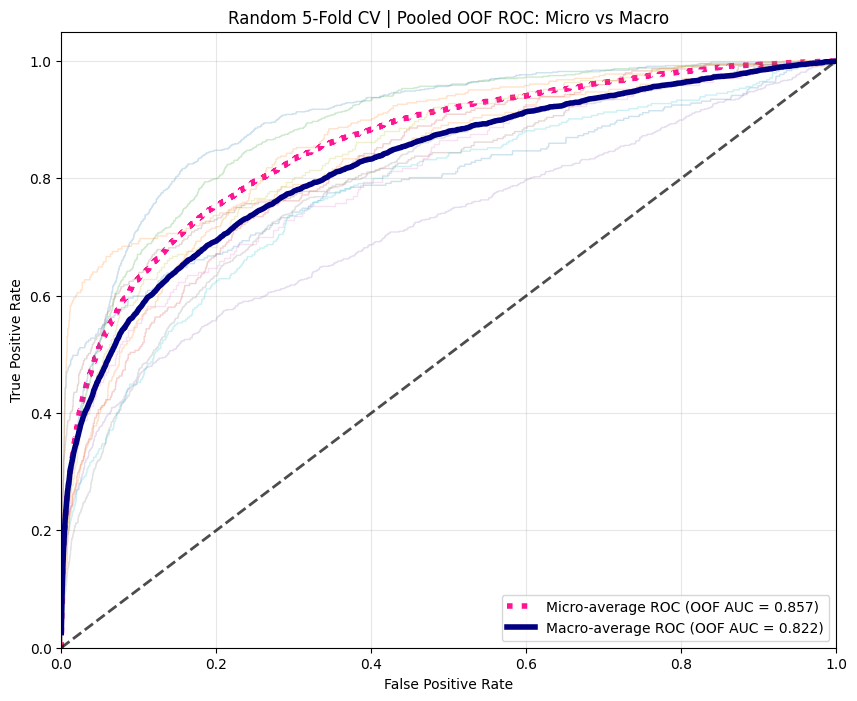

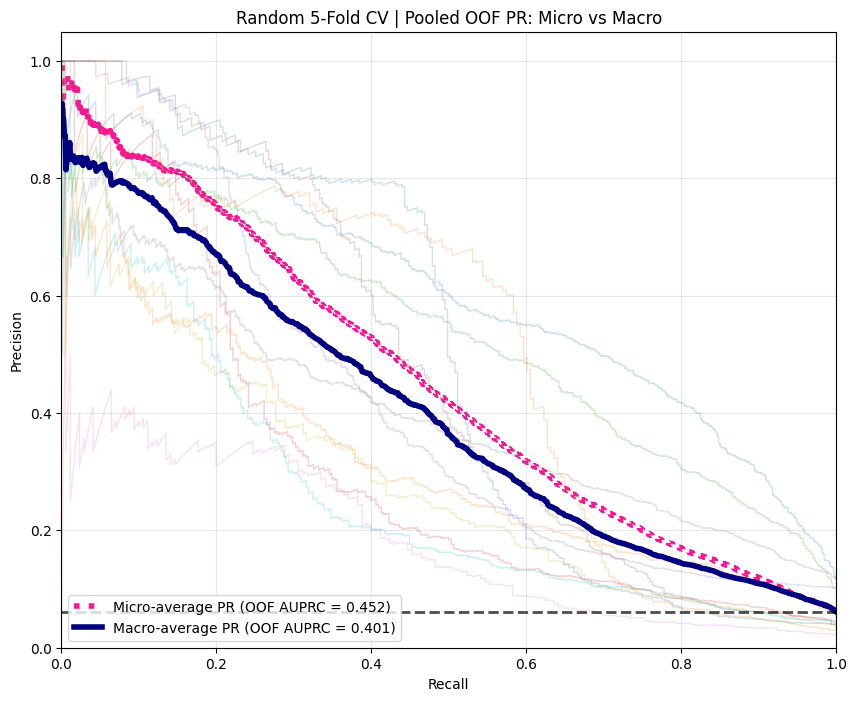

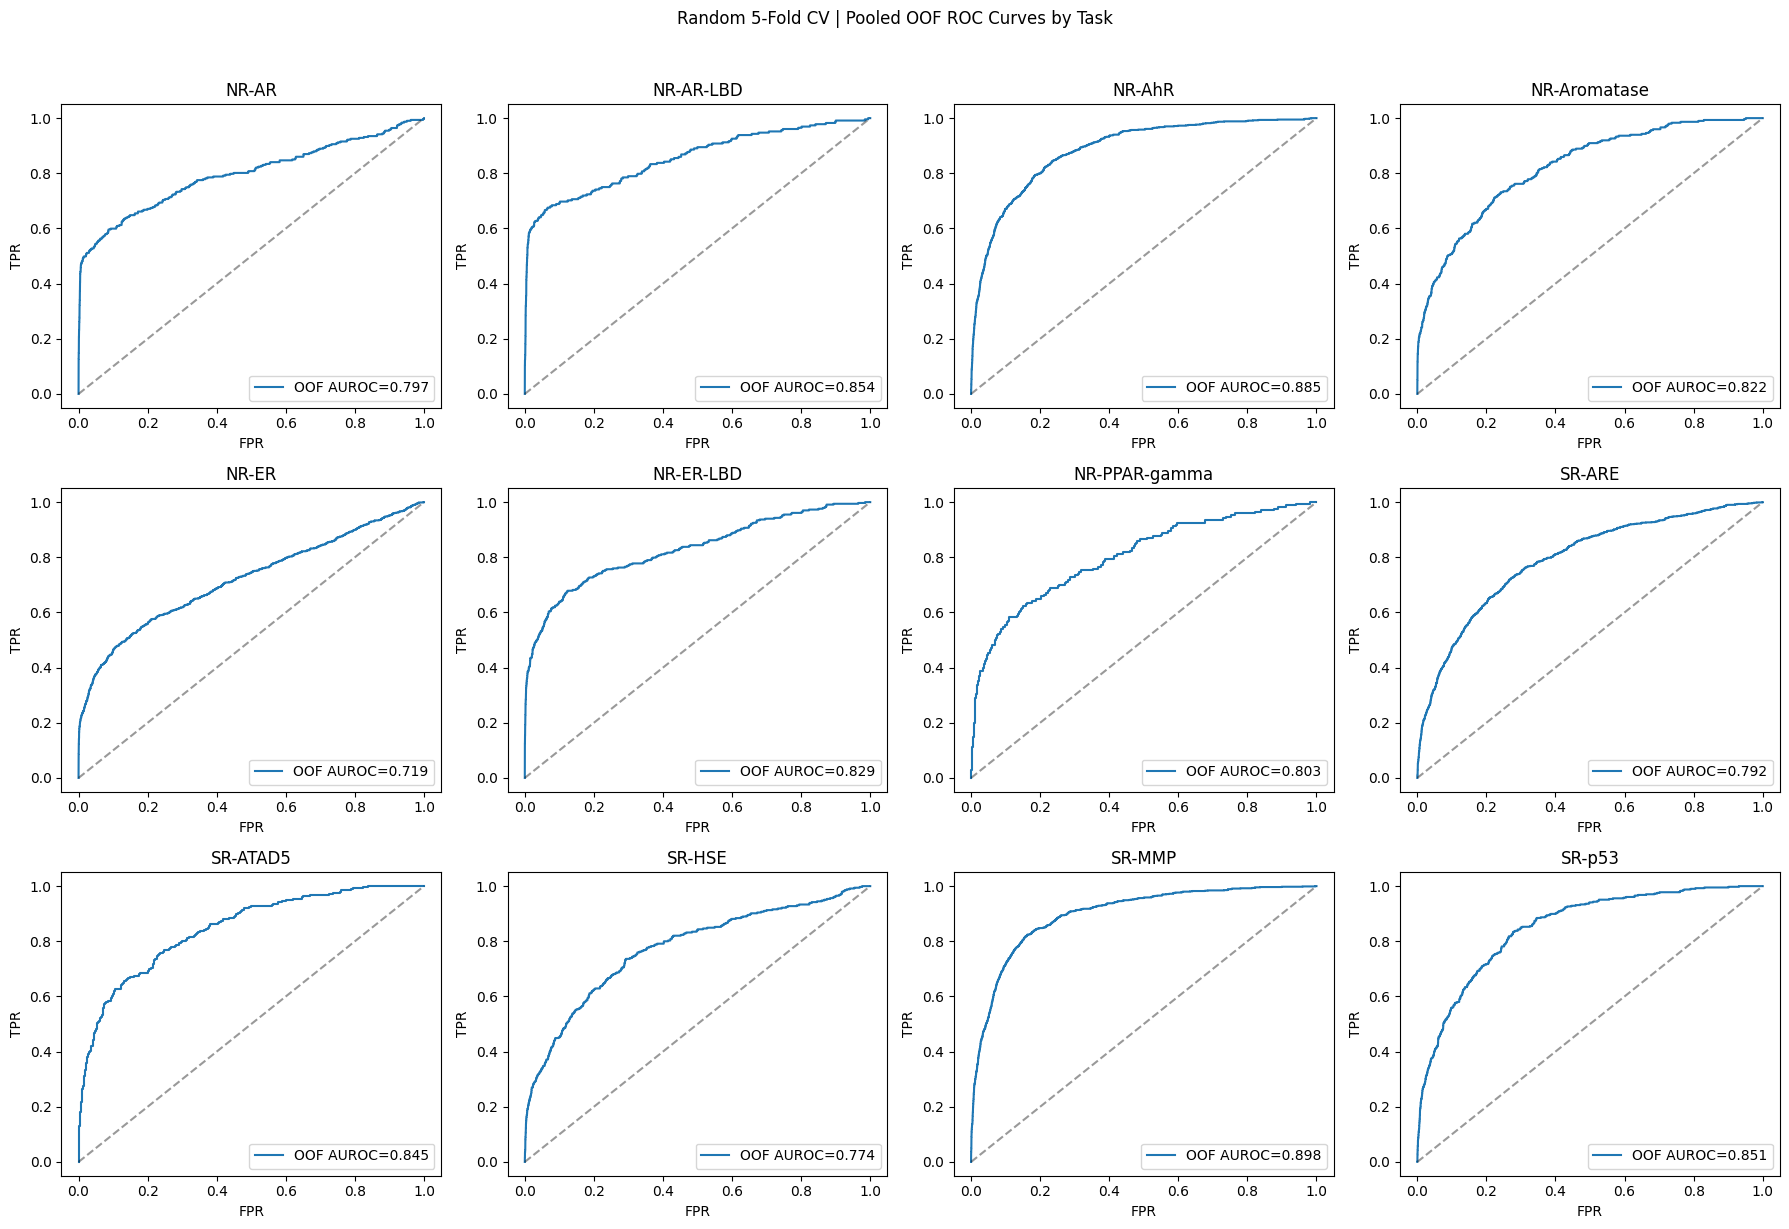

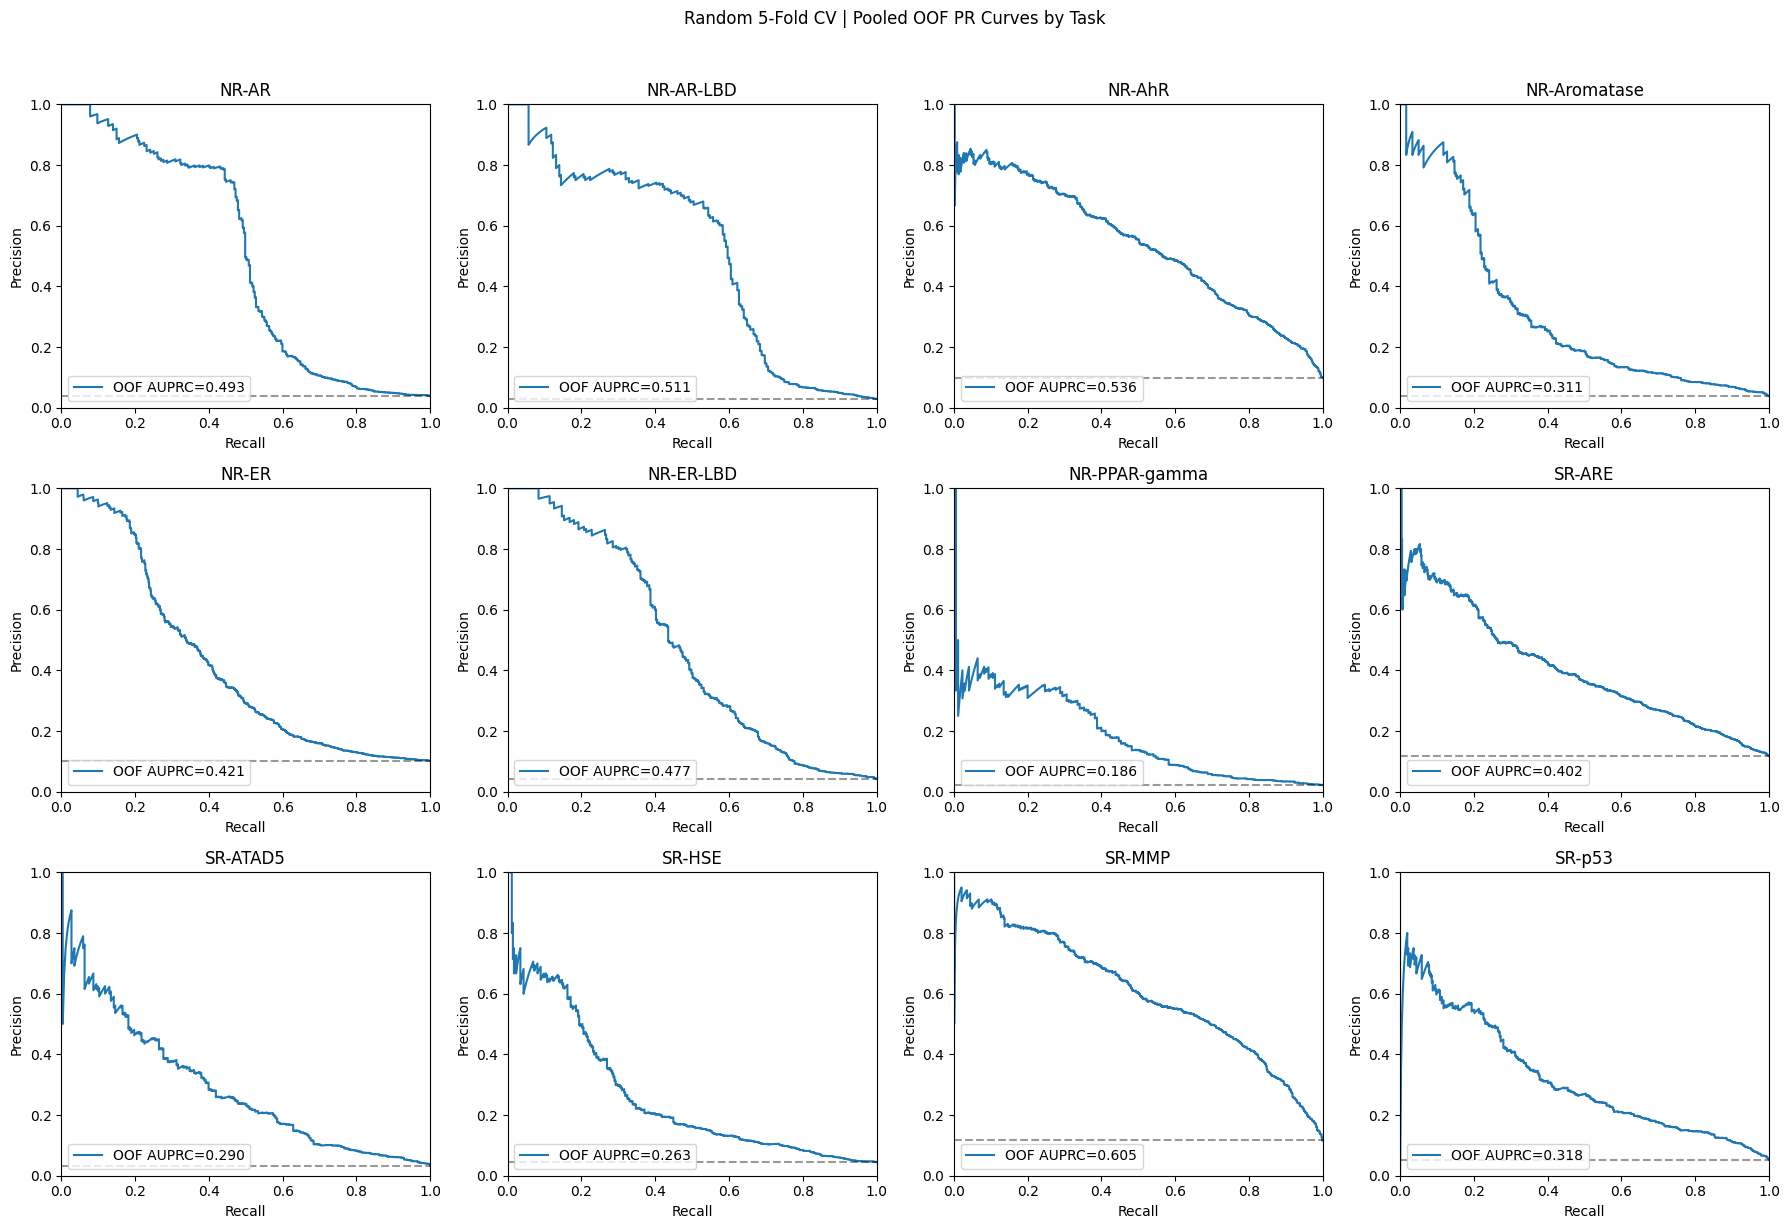


===== Multilabel Iterative Stratified 5-Fold CV =====
Fixed XGBoost hyperparameters:
{'max_depth': 7, 'n_estimators': 300, 'learning_rate': 0.03, 'reg_alpha': 1.0, 'gamma': 3, 'subsample': 0.8, 'colsample_bytree': 0.5, 'objective': 'binary:logistic'}

Fold balance diagnostics:


,fold,n_val,any_positive_rate,mean_task_positive_rate
0,1,1546,0.344114,0.061611
1,2,1546,0.369987,0.061287
2,3,1546,0.365459,0.061880
3,4,1546,0.373868,0.061341
4,5,1546,0.368693,0.061557


Fold-level global validation metrics:


,fold,n_val,macro_auroc,macro_auprc,micro_auroc,micro_auprc
0,1,1546,0.836954,0.425612,0.868666,0.460397
1,2,1546,0.823757,0.418392,0.855901,0.447837
2,3,1546,0.816331,0.414381,0.853119,0.453279
3,4,1546,0.817864,0.379597,0.853094,0.424561
4,5,1546,0.830702,0.418337,0.861710,0.468749


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.825122,0.008703,0.824138
1,macro_auprc,0.411264,0.018161,0.403371
2,micro_auroc,0.858498,0.006682,0.858387
3,micro_auprc,0.450965,0.016715,0.450274


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,SR-MMP,7730,0.116559,0.899373,0.601947,0.899805,0.018688,0.607553,0.042365,0.907633,0.003182,0.463576,0.025683,0.717593,0.030639,0.342916,0.025497
1,NR-AhR,7730,0.099353,0.880974,0.517434,0.881393,0.011944,0.521817,0.026971,0.916947,0.003761,0.391618,0.049155,0.719990,0.049454,0.270885,0.044423
2,SR-ATAD5,7730,0.032730,0.850939,0.313388,0.851570,0.023466,0.322067,0.062488,0.968693,0.001417,0.141027,0.041063,0.679048,0.111045,0.079035,0.024425
3,SR-p53,7730,0.052652,0.848679,0.314502,0.849194,0.013611,0.328185,0.058276,0.949547,0.002505,0.132154,0.061360,0.683846,0.237691,0.073803,0.036009
4,NR-AR-LBD,7730,0.029495,0.844068,0.546589,0.847255,0.046483,0.551119,0.021855,0.979301,0.001771,0.555542,0.060560,0.751425,0.038245,0.442409,0.064967
5,NR-ER-LBD,7730,0.043079,0.826603,0.483169,0.826108,0.035934,0.488296,0.059558,0.967270,0.001973,0.447994,0.041110,0.818430,0.079886,0.308900,0.031325
6,NR-Aromatase,7730,0.038551,0.819667,0.298697,0.820883,0.025806,0.309885,0.062599,0.963907,0.001852,0.161358,0.055097,0.760397,0.137574,0.090678,0.033051
7,NR-PPAR-gamma,7730,0.021992,0.813243,0.207989,0.815832,0.046210,0.228166,0.057470,0.978266,0.000738,0.065815,0.045055,0.600000,0.418330,0.035294,0.024608
8,NR-AR,7730,0.039715,0.806709,0.488422,0.808890,0.029943,0.492018,0.042574,0.973092,0.001919,0.558615,0.040381,0.799004,0.032690,0.429878,0.039600
9,SR-ARE,7730,0.117982,0.792122,0.391781,0.792164,0.004221,0.395641,0.029001,0.887581,0.003082,0.174383,0.033079,0.647995,0.064496,0.100919,0.020602


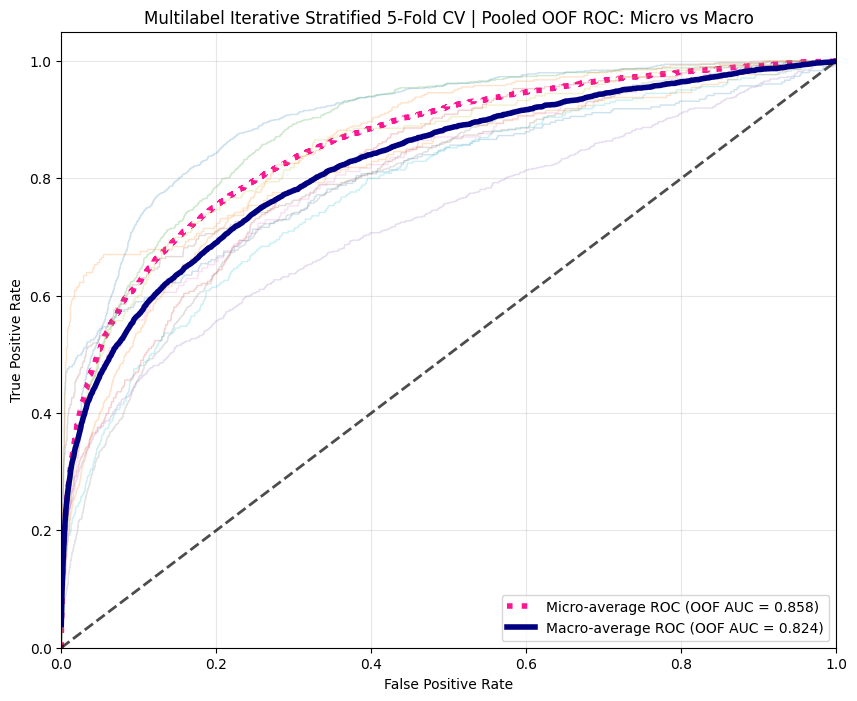

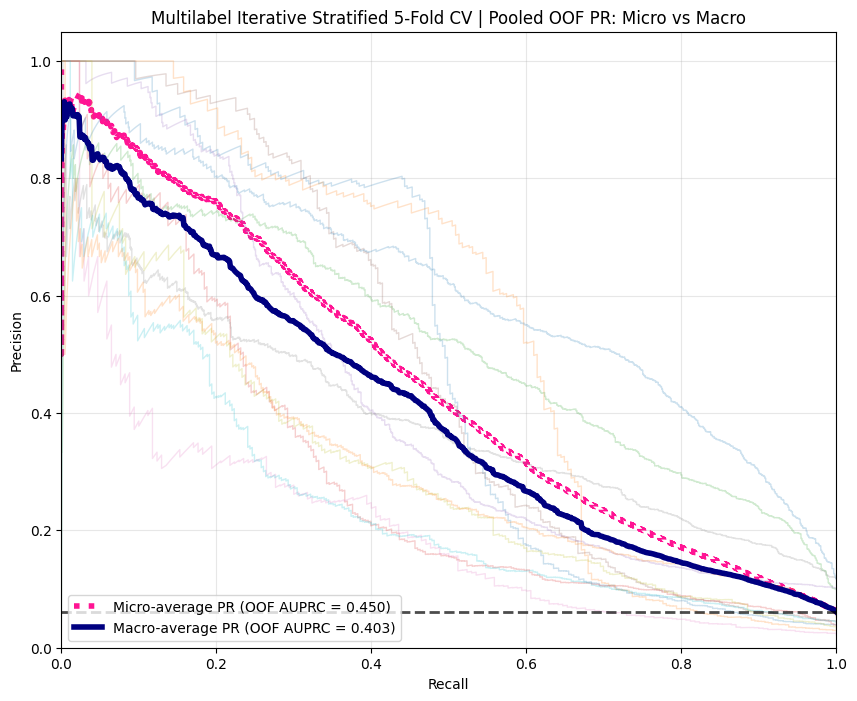

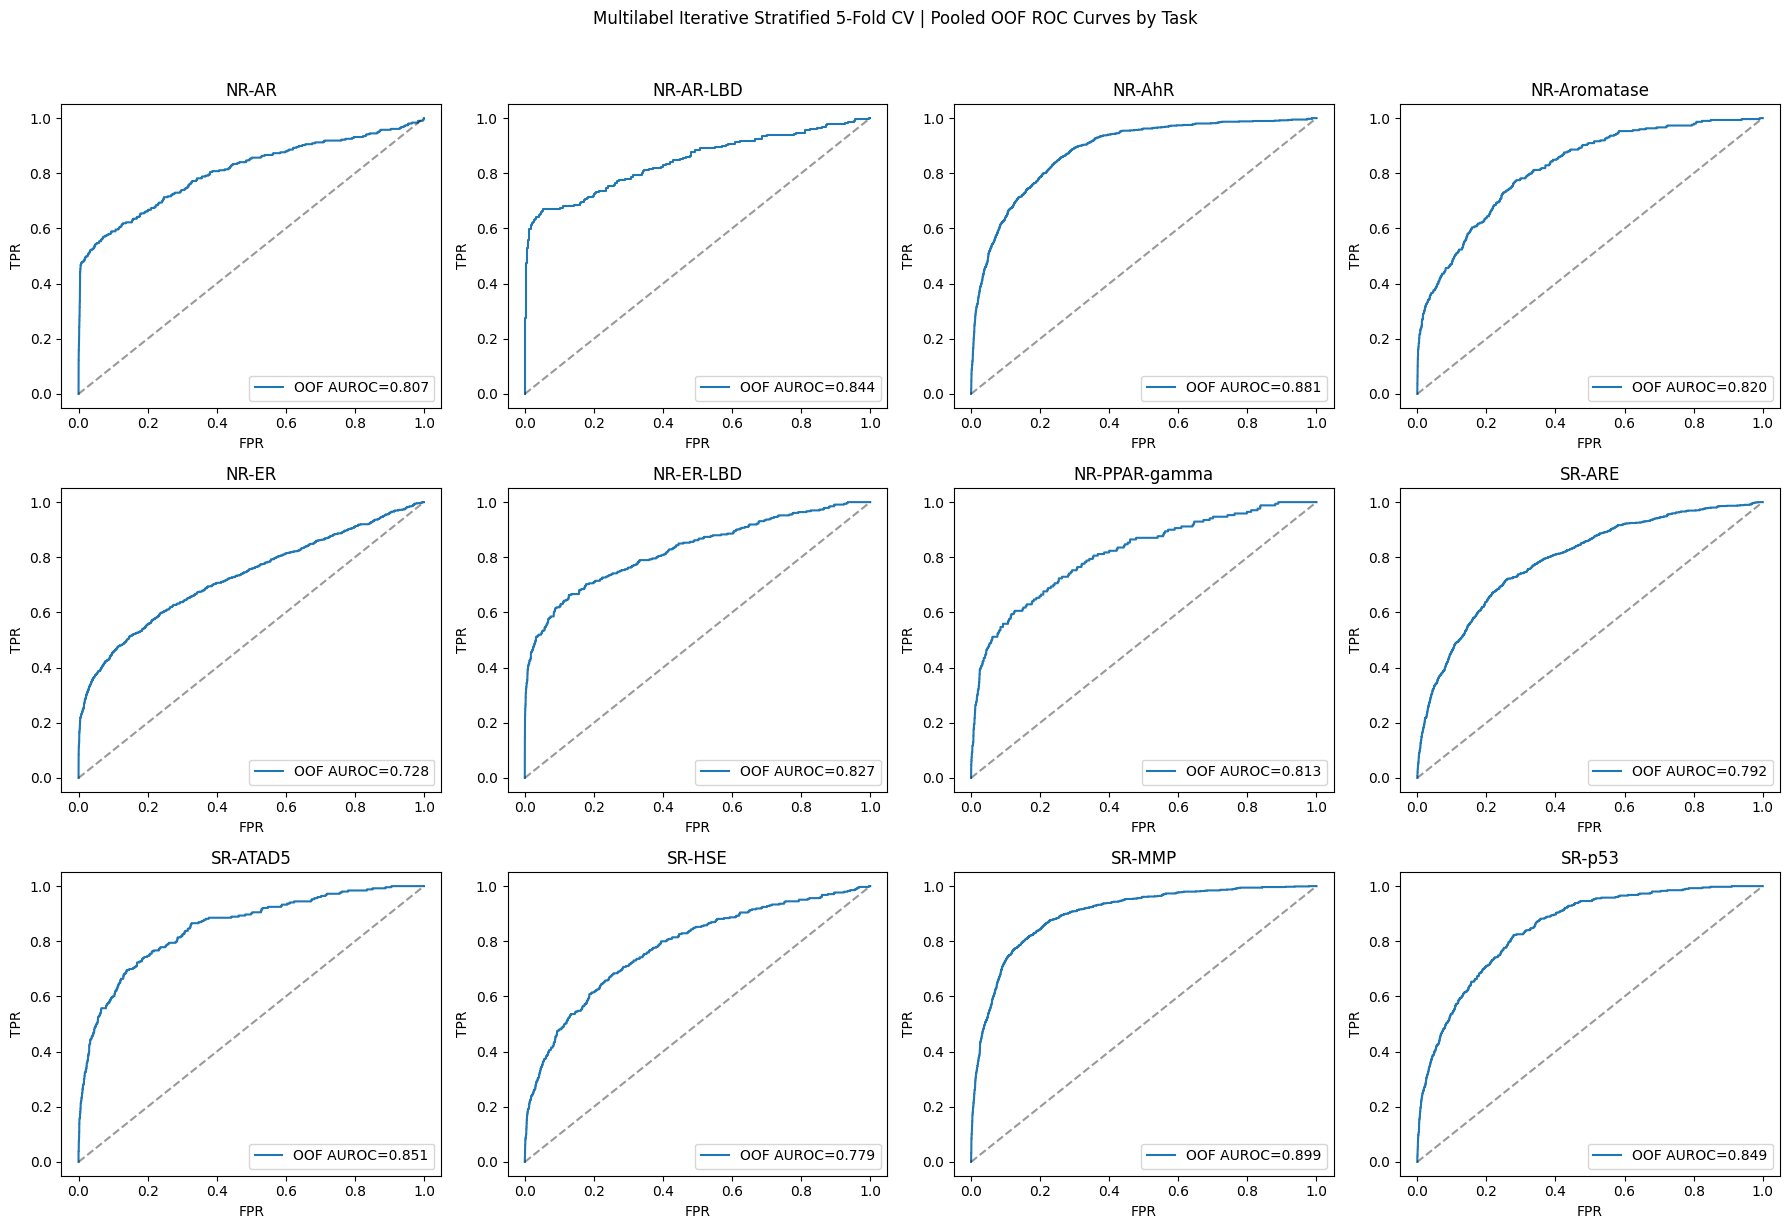

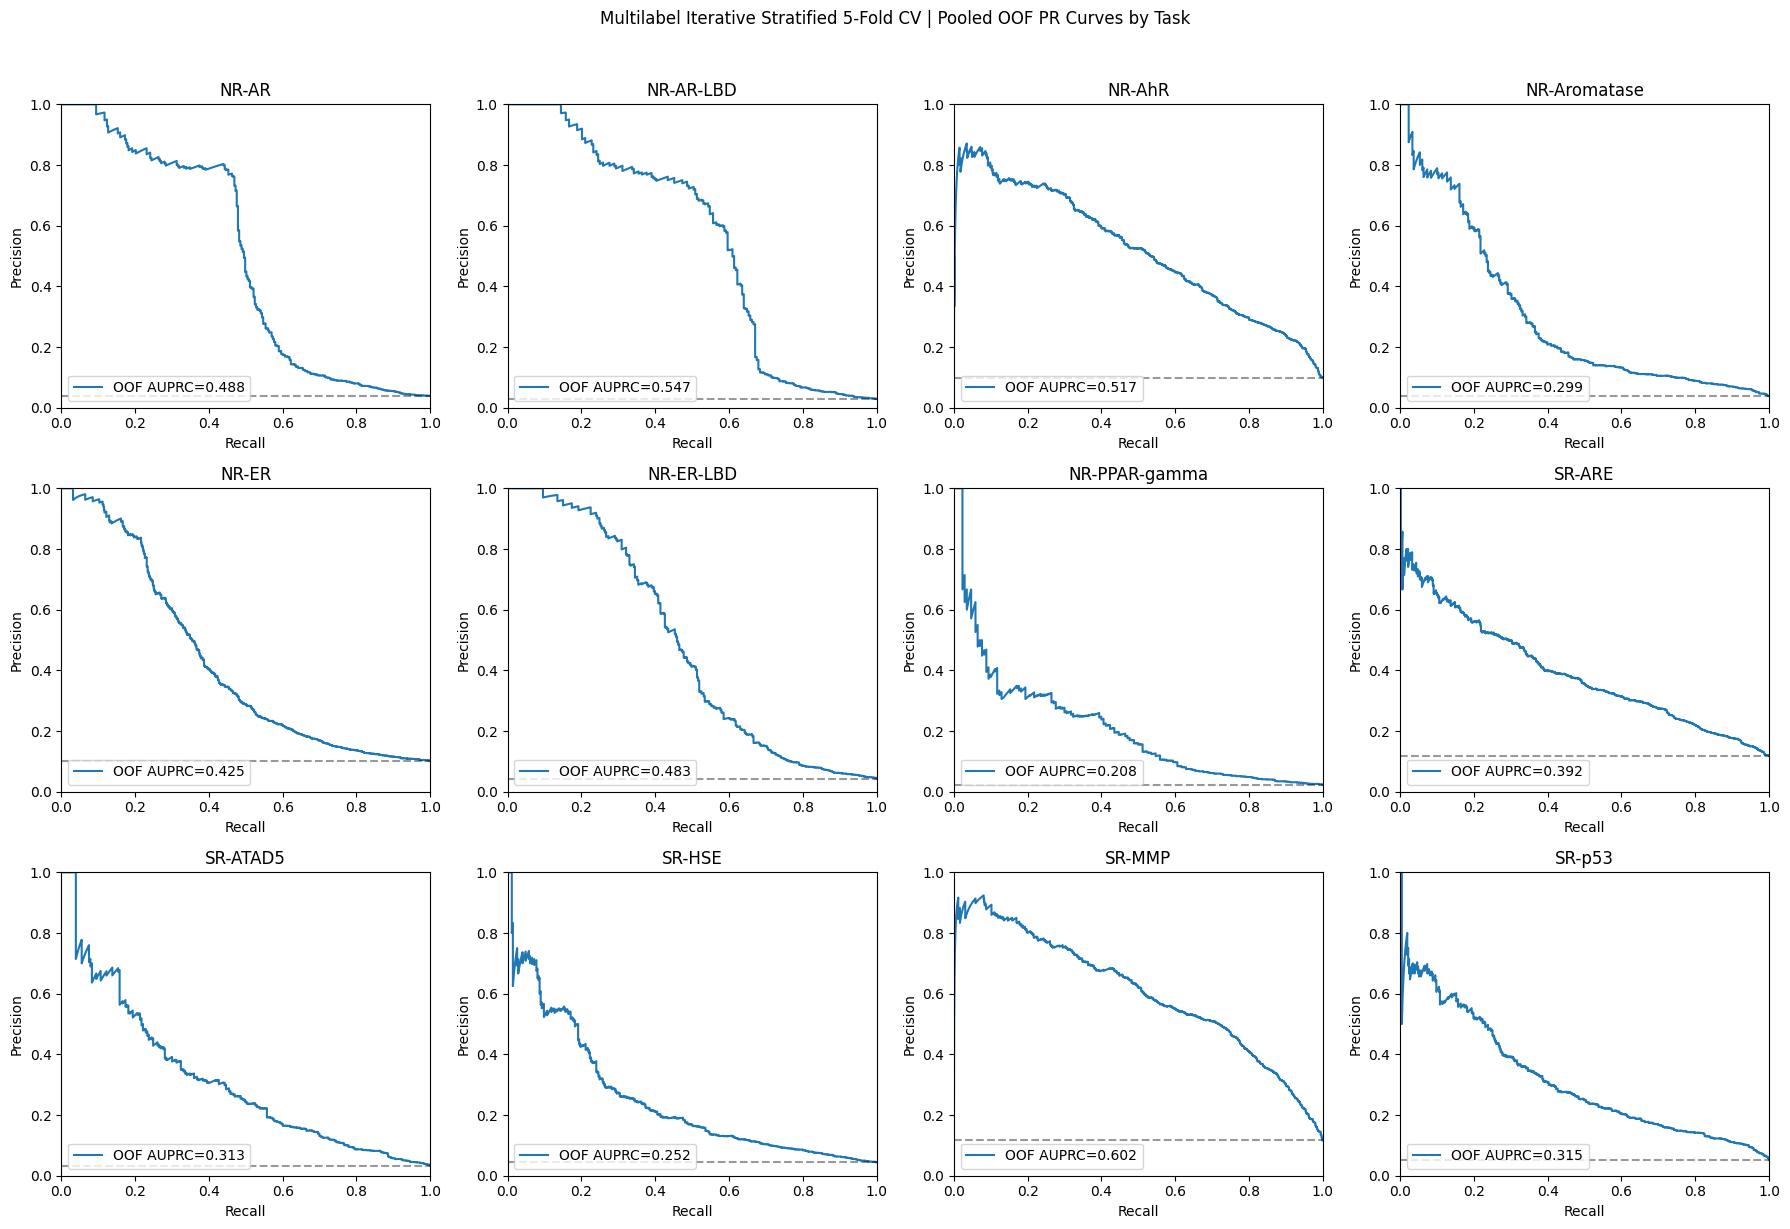

In [7]:
for strategy in STRATEGY_ORDER:
    result = experiment_results[strategy]

    print(f"\n===== {result['name']} =====")
    print("Fixed XGBoost hyperparameters:")
    print(result["fixed_params"])

    print("\nFold balance diagnostics:")
    display(result["fold_balance_df"])

    print("Fold-level global validation metrics:")
    display(result["fold_summary_df"])

    print("Reportable CV summary (mean/std across folds) + pooled OOF reference:")
    display(result["global_report_df"])

    print("Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):")
    display(result["task_summary_df"])

    plot_micro_macro_roc(result)
    plot_micro_macro_pr(result)
    plot_per_task_roc_grid(result, TASKS)
    plot_per_task_pr_grid(result, TASKS)

## 8. Final Comparison Snapshot

In [8]:
final_summary = comparison_df.copy()
final_summary

,strategy,strategy_label,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,0.824354,0.013191,0.822370,0.410770,0.021167,0.401032,0.857746,0.010683,0.857449,0.453595,0.022734,0.451835
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,0.825122,0.008703,0.824138,0.411264,0.018161,0.403371,0.858498,0.006682,0.858387,0.450965,0.016715,0.450274
